#  Chi-Square ($\chi^2$) Statistical Test

The **Chi-Square ($\chi^2$) test** is a foundational non-parametric statistical method used to analyze **categorical data**. While parametric tests (such as t-tests or ANOVA) evaluate differences between continuous numerical means, the Chi-Square test determines whether an association or structural difference exists based on **frequency distributions (counts)** across nominal or ordinal categories.



## 1. Core Operational Assumptions
To ensure the mathematical validity of a Chi-Square test, the underlying data framework must satisfy the following criteria:

*   **Categorical Measurement:** The variables must be nominal or ordinal (e.g., product types, regions, sentiment tiers).

*   **Independence of Observations:** Each subject or data point must contribute to exactly one cell in the contingency matrix. Repeated measures or paired samples cannot be analyzed with a standard Chi-Square test.

*   **Adequate Sample Size (Cochran’s Rule):** The mathematical approximation of the Chi-Square distribution requires that **every cell** has an expected frequency ($E$) of **at least 1**, and at least **80% of all cells** have an expected frequency of **5 or greater**.



## 2. Classifications of the Chi-Square Test

### A. Chi-Square Goodness-of-Fit Test

*   **Application:** Analyzes a single categorical variable.
*   **Objective:** To determine if an observed sample distribution fits a known theoretical, historical, or expected population distribution.
*   **Null Hypothesis ($H_0$):** The observed population distribution matches the specified theoretical distribution.

### B. Chi-Square Test of Independence

*   **Application:** Analyzes two distinct categorical variables cross-tabulated in a contingency table.
*   **Objective:** To evaluate whether the distribution of one variable is structurally independent of the other.
*   **Null Hypothesis ($H_0$):** There is no association between the two variables; they are statistically independent.



## 3. Mathematical Architecture & Formula Syntax

The test computes a global scalar metric ($\chi^2$) representing the aggregate normalized deviation of reality from a theoretical baseline:

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

Where:
*   $\mathbf{O}$ = **Observed Frequency:** The empirical count recorded in the sample dataset.
*   $\mathbf{E}$ = **Expected Frequency:** The theoretical count predicted under the assumption that the Null Hypothesis ($H_0$) is true.

### Computing Expected Frequencies ($E$)
*   **For Goodness-of-Fit:** 
    $$E_i = n \cdot p_i$$
    *(where $n$ is total sample size, and $p_i$ is the theoretical probability of category $i$)*
*   **For Independence (Contingency Tables):** 
    $$E_{r,c} = \frac{\text{Total Row } r \times \text{Total Column } c}{\text{Grand Total (N)}}$$

### Degrees of Freedom ($df$)
The degrees of freedom determine the exact shape of the underlying continuous Chi-Square distribution curve:
*   **Goodness-of-Fit:** $df = k - 1$ *(where $k$ is the total number of categories)*
*   **Test of Independence:** $df = (r - 1) \times (c - 1)$ *(where $r$ is the number of rows, and $c$ is the number of columns)*



## 4. Statistical Intuition & Mechanism

The Chi-Square test acts as a standardized variance aggregator for frequency matrices:

1.  **Establishing the Control Framework ($E$):** We model an idealized world where the Null Hypothesis is completely true (e.g., no bias, no relationship, perfect uniformity).

2.  **Quantifying Deviations $(O - E)$:** We measure the distance between our observed sample data and the idealized framework.

3.  **The Squaring Function $(O - E)^2$:** Squaring serves two vital purposes:
    *   It eliminates negative signs, preventing deviations in opposite directions from canceling each other out.
    *   It exponentially penalizes wider variances, making the test sensitive to outliers.

4.  **The Denominator Normalization $(\div E)$:** Dividing by the expected value scales the variance relative to magnitude. A variance of 10 units is highly volatile if the baseline expectation is 2, but statistically negligible if the baseline expectation is 10,000.

5.  **Critical Threshold Comparison:** The final compiled $\chi^2$ value is mapped onto a Chi-Square distribution curve corresponding to its specific degrees of freedom. If the probability ($p$-value) of observing a $\chi^2$ score this extreme is less than the significance alpha ($\alpha \le 0.05$), the variance cannot be reasonably attributed to sampling error. The Null Hypothesis is rejected in favor of an active structural effect.


In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.feature_selection import chi2

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


In [25]:
# Import The data from the CSV file
df = pd.read_csv('../DataSets/Titanic.csv')
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
778,779,0,3,"Kilgannon, Mr. Thomas J",male,NaN,0,0,36865,7.7375,NaN,Q
621,622,1,1,"Kimball, Mr. Edwin Nelson Jr",male,42.0,1,0,11753,52.5542,D19,S
783,784,0,3,"Johnston, Mr. Andrew G",male,NaN,1,2,W./C. 6607,23.4500,NaN,S
90,91,0,3,"Christmann, Mr. Emil",male,29.0,0,0,343276,8.0500,NaN,S
420,421,0,3,"Gheorgheff, Mr. Stanio",male,NaN,0,0,349254,7.8958,NaN,C


In [26]:
# Feature Construction:
df['Family'] = df['SibSp'] + df['Parch']

# Drop the columns that are not needed for analysis
df.drop(['Name', 'Ticket', 'Cabin','PassengerId','SibSp','Parch'], axis=1, inplace=True)
df.sample(5)

,Survived,Pclass,Sex,Age,Fare,Embarked,Family
642,0,3,female,2.0,27.9000,S,5
108,0,3,male,38.0,7.8958,S,0
383,1,1,female,35.0,52.0000,S,1
810,0,3,male,26.0,7.8875,S,0
766,0,1,male,NaN,39.6000,C,0


In [27]:
# Check For Missing values 
df.isna().sum().sort_values(ascending=False).head(5)

Age         177
Embarked      2
Survived      0
Pclass        0
Sex           0
dtype: int64

#### Observation:
- Age has ~ 20% missing values so will impute the mean age.
- Fare has ~ 1% missing values so will drop those 2 rows from the dataset.

In [28]:
data = df.copy()

# 1. Drop rows with missing Embarked
data = data.dropna(subset=['Embarked'], axis=0)

# 2. Impute Age with mean age
data['Age'] = data['Age'].fillna(data['Age'].mean())

# 3. Bin Age and Fare into categorical buckets so chi2(Only valid for Categorical Variable)
data['AgeBin'] = pd.cut(data['Age'], bins=[0,12,18,35,60,100],
                        labels=['Child','Teen','YoungAdult', 'Adult', 'Senior'])

data['FareBin'] = pd.qcut(data['Fare'], q=4,
                         labels=['Low','Medium','High','Very High'])

data.sample(5)

,Survived,Pclass,Sex,Age,Fare,Embarked,Family,AgeBin,FareBin
3,1,1,female,35.000000,53.1000,S,1,YoungAdult,Very High
712,1,1,male,48.000000,52.0000,S,1,Adult,Very High
549,1,2,male,8.000000,36.7500,S,2,Child,Very High
778,0,3,male,29.642093,7.7375,Q,0,YoungAdult,Low
585,1,1,female,18.000000,79.6500,S,2,Teen,Very High


**Note on binning:** 
-Chi-square needs discrete categories with reasonably
sized bins — this is a manual choice (a "researcher degree of freedom"), and
it's worth remembering that different bin boundaries can change the p-value.

Always mention how you binned when you report a chi2 result on a continuous
feature.

# Chi-Square Feature Selection Pipeline

## 1. Input Parameter: The Contingency Table

### `contingency = pd.crosstab(data[feature], data[target])`

*   **What it is:** A raw frequency matrix (cross-tabulation table) counting occurrences across combined categories.
*   **Structure:** The unique classes of your `[feature]` form the rows, and the unique classes of your `[target]` form the columns.
*   **Mathematical Constraint:** Cells must contain **absolute frequencies (counts)**. Passing percentages, means, or normalized ratios into `chi2_contingency` will invalidate the test metrics completely.

---

## 2. Decoupling the Output Elements

### A. `stat` ($\chi^2$ Test Statistic)
*   **What it represents:** The cumulative total of normalized squared deviations between your observed counts and expected counts: $\sum \frac{(O-E)^2}{E}$.

*   **Range:** $[0, +\infty)$

*   **Interpretation for Feature Selection:** 
    *   **Near 0:** The feature distribution matches the target distribution perfectly by random chance. The feature holds no predictive power.
    *   **High Value:** The feature and target are heavily dependent on each other. **Higher numbers indicate a stronger signal for your model.**

### B. `p_value` (Probability Value)
*   **What it represents:** The probability of obtaining a test statistic at least as extreme as `stat`, assuming the feature has absolutely zero relationship with the target (Null Hypothesis is true).

*   **Range:** $[0, 1]$

*   **Interpretation for Feature Selection:**
    *   **$p \le 0.05$ (Statistically Significant):** Reject the null hypothesis. The feature holds a genuine, non-random relationship with the target. **Keep this feature.**
    *   **$p > 0.05$ (Statistically Insignificant):** The observed relationship can easily be explained by random sampling noise. **Drop this feature.**

### C. `dof` (Degrees of Freedom)

*   **What it represents:** The number of independent cell values in your contingency table that are free to vary given fixed row and column totals.
*   **Mathematical Derivation:** $dof = (\text{Rows} - 1) \times (\text{Columns} - 1)$

*   **Range:** $[1, +\infty)$ integers.

*   **Interpretation for Feature Selection:** It dictates the shape of the $\chi^2$ distribution curve used to calculate your `p_value`. High-cardinality features (features with many unique categories) inherently produce massive `dof` values.

### D. `expected` (Expected Frequency Matrix)
*   **What it represents:** A generated 2D NumPy array mirroring the shape of your `contingency` table. It shows what your table data *would look like* if your feature and target had zero correlation.

*   **Range:** $[0, +\infty)$ continuous floats.

*   **Interpretation for Feature Selection:** Used purely for **pipeline validation**. Check this array to ensure the test assumptions hold up (Cochran's Rule: no expected values $< 1$, and less than 20% of values are $< 5$). If this rule is broken, your calculated `p_value` cannot be trusted.

---

## 3. Feature Selection Application & Strategic Rules

Using this exact code block to automate feature filtering introduces several strict advantages and pitfalls:

| Strategic Rule | Description |
| :--- | :--- |
| **Data Scope Limitations** | This approach **only** works if both `data[feature]` and `data[target]` are categorical. If your target or feature is a continuous numeric float (like Income or Age), you must bin the data first or use an Alternative test (like ANOVA or Mutual Information Score). |
| **Automating the Drop Strategy** | In an automated pipeline, pass your target and iterate through all categorical features in a loop. Drop any feature where the returned `p_value` is strictly greater than your threshold (typically $\alpha = 0.05$). |
| **Ranking Feature Importance** | You **cannot** safely use `stat` alone to rank feature importance if your features have a different number of categories. A feature with 10 categories will inherently yield a much higher `stat` than a feature with 2 categories. To rank features cleanly, rank them in **ascending order of their `p_value`**. |


## Chi-Square Test of Independence

In [29]:
def chi2_feature_report(data, feature, target="Survived",alpha=0.05 ,plot=True):
    
    """
    This Function will perform Chi-Square test for categorical features and Target.
    It will return contingency table, statistic, dof, p-value, and plot the
    survival breakdown by category.
    """
    
    contingency = pd.crosstab(data[feature], data[target])
    stat, p_value, dof, expected = chi2_contingency(contingency)
    
    print(f"-------- {feature} vs {target} -------- ")
    print("H0 : Feature and Target are independent (No Association)")
    print("\n Contingency table (Observed Counts): ")
    print(contingency)
    
    print(f"\nChi2 Statistic: {stat:.4f}")
    print(f"P-Value: {p_value:.4f}")
    print(f"Degrees of Freedom: {dof}")
    
    minimum_expected = expected.min()
    print(f"Smallest expected frequency : {minimum_expected:.2f}","(should be >= 5 for Chi-Square test)")
    
    if p_value < alpha:
        print(f"=> p < {alpha}, REJECT H0: '{feature}' appears to be associated with '{target}'.")
    else:
        print(f"=> p > {alpha}, ACCEPT H0: '{feature}' does not appear to be associated with '{target}'.")
        
    
    if plot:
        prop = pd.crosstab(data[feature], data[target], normalize='index')
        prop.plot(kind="bar", stacked=True, figsize=(5.5, 3.5),
                   color=["#e74c3c", "#27ae60"])
        
        plt.title(f"Chi-Square Test for '{feature}' vs '{target}'")
        plt.ylabel('Proportion')
        plt.xlabel(feature)
        plt.legend(['Died', 'Survived'],bbox_to_anchor=(1.02, 1),loc="upper right")
        plt.tight_layout()
        plt.show()
    
    return {"Feature": feature, "chi2": stat, "DOF": dof, "p_value": p_value, 
            "Minimum expected": minimum_expected}




## Feature : `Pclass`

**Hypothesis:** Passenger class likely reflects deck location / rescue
priority, so expect a strong association.

-------- Pclass vs Survived -------- 
H0 : Feature and Target are independent (No Association)

 Contingency table (Observed Counts): 
Survived    0    1
Pclass            
1          80  134
2          97   87
3         372  119

Chi2 Statistic: 100.9804
P-Value: 0.0000
Degrees of Freedom: 2
Smallest expected frequency : 70.37 (should be >= 5 for Chi-Square test)
=> p < 0.05, REJECT H0: 'Pclass' appears to be associated with 'Survived'.


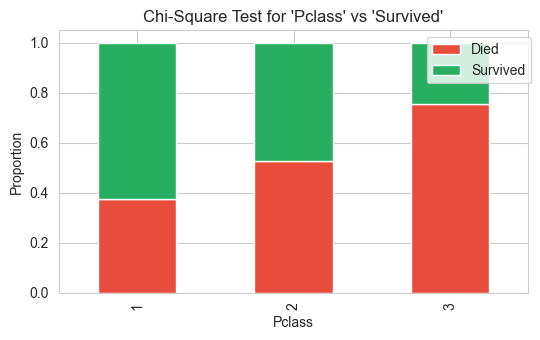

In [30]:
results = []

results.append(chi2_feature_report(data, "Pclass"))

**Conclusion:** Pclass shows a clear, expected pattern — 1st class survival
rate is far higher than 3rd class, and the test rejects H0 comfortably.
This lines up with the well-known "women and 1st class first" historical
account of the evacuation.

## Feature : `Sex`

**Hypothesis:** "Women and children first" — expect the strongest
association of any feature here.

-------- Sex vs Survived -------- 
H0 : Feature and Target are independent (No Association)

 Contingency table (Observed Counts): 
Survived    0    1
Sex               
female     81  231
male      468  109

Chi2 Statistic: 258.4266
P-Value: 0.0000
Degrees of Freedom: 1
Smallest expected frequency : 119.33 (should be >= 5 for Chi-Square test)
=> p < 0.05, REJECT H0: 'Sex' appears to be associated with 'Survived'.


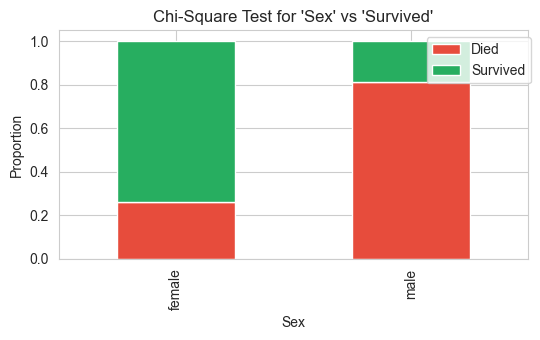

In [31]:
results.append(chi2_feature_report(data, "Sex"))

**Conclusion:** This is expected to be (and typically is) the single
largest chi2 statistic in the dataset — the survival gap between men and
women is the dominant signal in Titanic data. Anything downstream (e.g. a
model) that ignores `Sex` will underperform badly.

## 5. Feature: `Embarked`

**Hypothesis:** Weaker, indirect signal — port of embarkation correlates
with class/fare distribution rather than survival directly, so expect a
moderate rather than dominant effect.

-------- Embarked vs Survived -------- 
H0 : Feature and Target are independent (No Association)

 Contingency table (Observed Counts): 
Survived    0    1
Embarked          
C          75   93
Q          47   30
S         427  217

Chi2 Statistic: 26.4891
P-Value: 0.0000
Degrees of Freedom: 2
Smallest expected frequency : 29.45 (should be >= 5 for Chi-Square test)
=> p < 0.05, REJECT H0: 'Embarked' appears to be associated with 'Survived'.


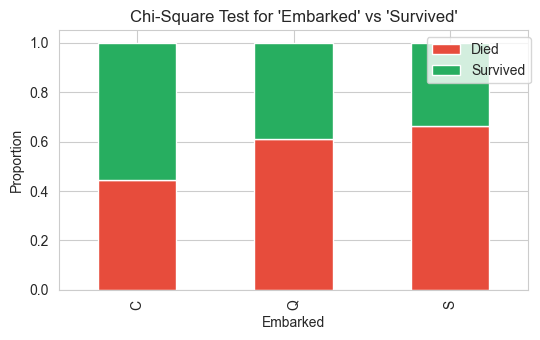

In [32]:
results.append(chi2_feature_report(data, "Embarked"))

**Conclusion:** Significant, but the *effect* is smaller than Pclass/Sex.
This is a good example of statistical significance != practical importance —
check the chi2 statistic magnitude, not just the p-value, when ranking
features later.

## Feature: `Family`
**Hypothesis:** "Children first" suggests the Child bucket should show a
survival bump.

-------- Family vs Survived -------- 
H0 : Feature and Target are independent (No Association)

 Contingency table (Observed Counts): 
Survived    0    1
Family            
0         374  161
1          72   89
2          43   59
3           8   21
4          12    3
5          19    3
6           8    4
7           6    0
10          7    0

Chi2 Statistic: 81.6837
P-Value: 0.0000
Degrees of Freedom: 8
Smallest expected frequency : 2.29 (should be >= 5 for Chi-Square test)
=> p < 0.05, REJECT H0: 'Family' appears to be associated with 'Survived'.


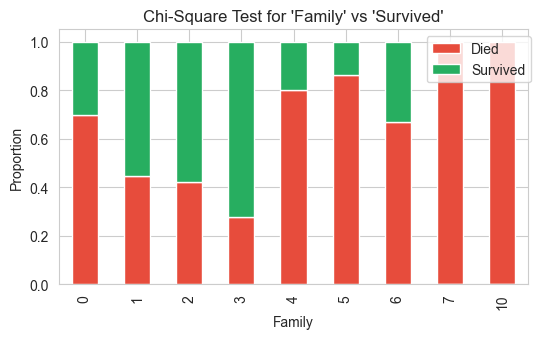

In [33]:
results.append(chi2_feature_report(data, "Family"))

## Feature: `AgeBin` (binned)

**Hypothesis:** "Children first" suggests the Child bucket should show a
survival bump.

-------- AgeBin vs Survived -------- 
H0 : Feature and Target are independent (No Association)

 Contingency table (Observed Counts): 
Survived      0    1
AgeBin              
Child        29   40
Teen         40   30
YoungAdult  346  189
Adult       117   77
Senior       17    4

Chi2 Statistic: 17.3755
P-Value: 0.0016
Degrees of Freedom: 4
Smallest expected frequency : 8.03 (should be >= 5 for Chi-Square test)
=> p < 0.05, REJECT H0: 'AgeBin' appears to be associated with 'Survived'.


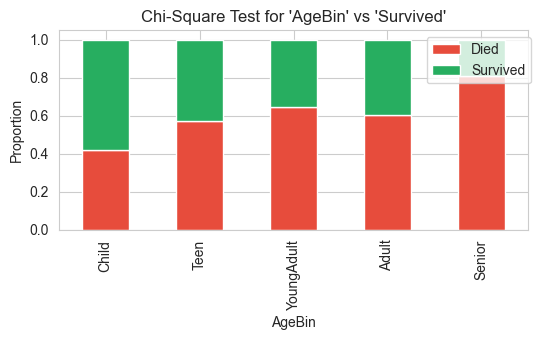

In [34]:
results.append(chi2_feature_report(data, "AgeBin"))

**Conclusion:** Watch whether Child shows the expected bump. Remember this
result is conditional on the bin edges chosen in Step 1 — re-binning
(e.g. a straight <=16 vs >16 split) could shift the p-value and statistic
somewhat, even if the broad conclusion holds.

## Feature: `FareBin` (binned)

**Hypothesis:** Fare is a finer-grained proxy for class/wealth, expect a
strong association similar in spirit to Pclass.

-------- FareBin vs Survived -------- 
H0 : Feature and Target are independent (No Association)

 Contingency table (Observed Counts): 
Survived     0    1
FareBin            
Low        179   44
Medium     156   68
High       121  101
Very High   93  127

Chi2 Statistic: 78.5613
P-Value: 0.0000
Degrees of Freedom: 3
Smallest expected frequency : 84.14 (should be >= 5 for Chi-Square test)
=> p < 0.05, REJECT H0: 'FareBin' appears to be associated with 'Survived'.


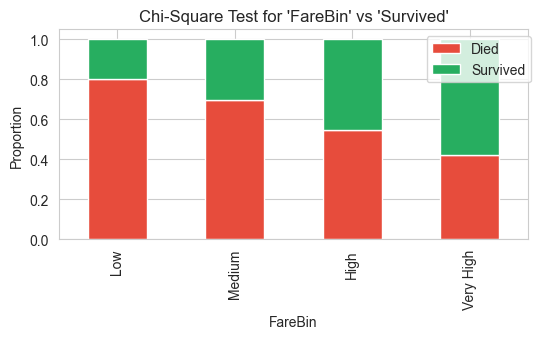

In [35]:
results.append(chi2_feature_report(data, "FareBin"))

## Manual Results - Summary Table

In [36]:
summary = pd.DataFrame(results).sort_values("chi2", ascending=False).reset_index(drop=True)
summary

,Feature,chi2,DOF,p_value,Minimum expected
0,Sex,258.426610,1,3.779910e-58,119.325084
1,Pclass,100.980407,2,1.181362e-22,70.371204
2,Family,81.683656,8,2.239008e-14,2.294713
3,FareBin,78.561331,3,6.245892e-17,84.139483
4,Embarked,26.489150,2,1.769922e-06,29.448819
5,AgeBin,17.375493,4,1.633738e-03,8.031496


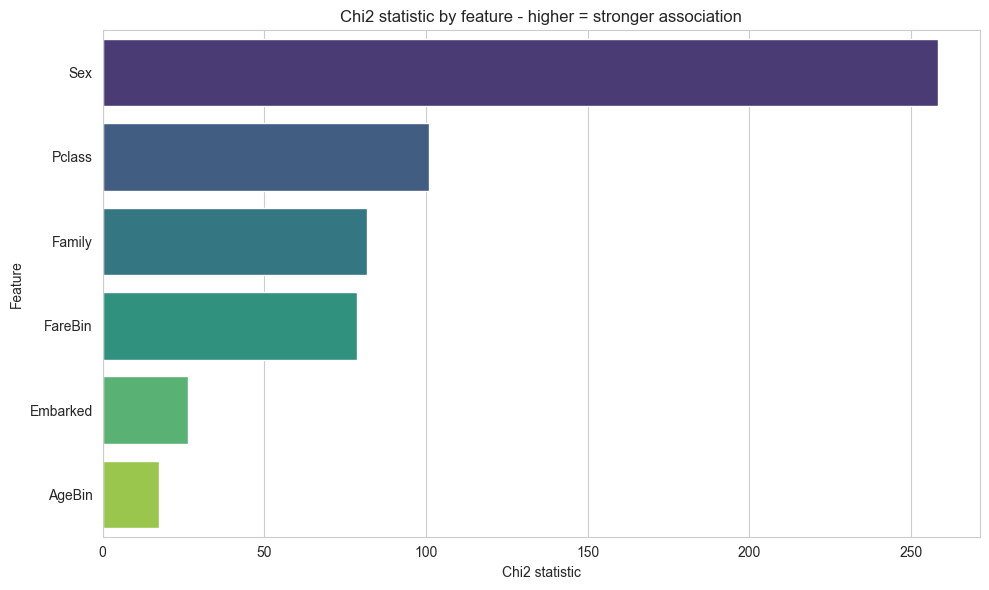

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary,
    x="chi2",
    y="Feature",
    palette="viridis",
    hue="Feature",
    legend=False
)

plt.title("Chi2 statistic by feature - higher = stronger association")
plt.xlabel("Chi2 statistic")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Selecting K best and Training Logistic Regression Mode

In [38]:
data.sample(2)

,Survived,Pclass,Sex,Age,Fare,Embarked,Family,AgeBin,FareBin
64,0,1,male,29.642093,27.7208,C,0,YoungAdult,High
443,1,2,female,28.000000,13.0000,S,0,YoungAdult,Medium


In [57]:
from sklearn.feature_selection import SelectKBest
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Define the feature selection pipeline
def Model_report(X, y, features, method="sklearn", manual_summary=None, k_best=1):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Manual chi-square feature selection
    if method == "manual":
        if k_best == "all":
            selected_features = features
        else:
            if k_best > len(manual_summary):
                
                raise ValueError(
                f"k_best={k_best}, but only "
                f"{len(manual_summary)} features are available."
            )
            selected_features = manual_summary.head(k_best)["Feature"].tolist()
            print(f"Manual Selected features: {selected_features}")
    
        preprocessor = ColumnTransformer(
            transformers=[
                ("categorical", OneHotEncoder(handle_unknown='ignore'), selected_features),
                
            ]
        )
        
        model = Pipeline([
            ("encoding", preprocessor),
            ("logistic_regression", LogisticRegression(max_iter=1000))
        ])
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(classification_report(y_test, y_pred))
            
        return model

    # Built-in sklearn chi-square feature selection
    elif method == "sklearn":
        
        preprocessor = ColumnTransformer(
            transformers=[
                (
                    "categorical",
                    OneHotEncoder(handle_unknown="ignore"),
                    features
                )
            ], verbose_feature_names_out=False)
        
        model = Pipeline([
            ("encoding", preprocessor),
            ("K_best", SelectKBest(score_func=chi2, k=k_best)),
            ("Logistic Regression", LogisticRegression(max_iter=1000))
        ])
        
        model.fit(X_train, y_train)
        
        # Extracting Selected features 
        encoded_features = model.named_steps["encoding"].get_feature_names_out()
        selector = model.named_steps["K_best"]
        
        selected_features = encoded_features[selector.get_support()]
        print(f"----- Selected Features -----")
        print(selected_features)
        
        selected_score = pd.DataFrame({
            "Features" : encoded_features,
            "Chi2 Score" : selector.scores_,
            "P_value " : selector.pvalues_
        })
        
        selected_score = selected_score[selector.get_support()].sort_values("Chi2 Score", ascending=False)
        
        y_pred = model.predict(X_test)
        
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(classification_report(y_test, y_pred))
        
        return selected_score, model
    
    else:
        raise ValueError("Invalid method. Choose from 'manual' or 'sklearn'.")


In [58]:
features = ["Sex","Pclass", "Family", "FareBin", "Embarked", "AgeBin"]

x = data[features]
y = data["Survived"]

Model_report(x, y, features, method="manual", manual_summary=summary, k_best=3)

Manual Selected features: ['Sex', 'Pclass', 'Family']
Accuracy: 0.7809
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       110
           1       0.74      0.66      0.70        68

    accuracy                           0.78       178
   macro avg       0.77      0.76      0.76       178
weighted avg       0.78      0.78      0.78       178



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('encoding', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Sex','Pclass','Family','FareBin','Embarked','AgeBin']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining colu

## Cross Check With Sklearn 

In [61]:
features = ["Sex","Pclass", "Family", "FareBin", "Embarked", "AgeBin"]
X_sklearn  = data[features].copy()
y_sklearn = data['Survived']

report, model = Model_report(X_sklearn, y_sklearn ,features, method="sklearn",k_best=10)


----- Selected Features -----
['Sex_female' 'Sex_male' 'Pclass_1' 'Pclass_3' 'Family_1' 'Family_2'
 'Family_3' 'FareBin_Low' 'FareBin_Very High' 'Embarked_C']
Accuracy: 0.7640
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       110
           1       0.70      0.68      0.69        68

    accuracy                           0.76       178
   macro avg       0.75      0.75      0.75       178
weighted avg       0.76      0.76      0.76       178



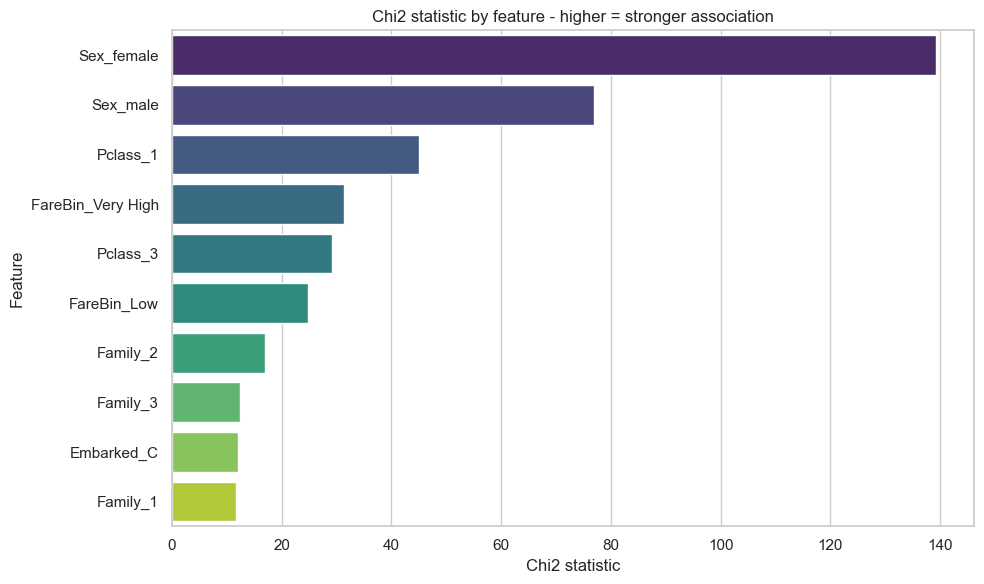

In [62]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=report,
    x="Chi2 Score",
    y="Features",
    palette="viridis",
    hue="Features",
    legend=False
)

plt.title("Chi2 statistic by feature - higher = stronger association")
plt.xlabel("Chi2 statistic")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##  Executive Summary & Root Cause of the Discrepancy

The significant difference between  manual calculation (`chi2` using `scipy.stats.chi2_contingency`) and `Chi2_sklearn` stems from a fundamental difference in what these functions are mathematically designed to do:

*   **`chi2_contingency` (Your `chi2`):** Computes a **Test of Independence** on a 2D contingency table. It tests if the distribution of a feature depends on the target variable.

*   **`sklearn.feature_selection.chi2` (Your `Chi2_sklearn`):** Computes a **Goodness-of-Fit Test** across 1D arrays. It treats features as frequency weights or numerical values directly rather than computing cross-tabulations. For categorical features, `sklearn` requires your input features to be explicitly **One-Hot Encoded (dummy variables)** before processing. 

Because you passed raw categorical labels (e.g., encoded as integers or strings) into Scikit-Learn instead of one-hot encoded vectors, Scikit-Learn performed mathematical operations on the *label codes themselves* (treating them as direct numeric frequencies). This yielded incorrect, smaller statistics and conflicting p-values.






**Why the numbers won't match exactly:** the manual test used the *raw*
category groupings straight from `pd.crosstab`. sklearn's version ran on
label-encoded integers — for a feature like `Pclass` (already numeric-ish)
this barely matters, but for `Embarked`/`Sex` the encoding order is
arbitrary and this is fine for chi2 (unlike for a linear model) since chi2
treats each integer as a distinct category, not a magnitude. The
**ranking of features by strength should still roughly agree** even if the
exact statistic differs slightly — that agreement is your sanity check that
you're applying the sklearn call correctly.

## When NOT to trust a chi2 result


- **Sparse cells:** if any expected cell count < 5 (check the
  `min_expected` printed for `SibSp`/`Parch` above), the chi2
  approximation to the true sampling distribution weakens. Fix: merge rare
  categories, or use Fisher's exact test for small 2x2 tables.

- **Continuous features:** chi2 needs discretization first (as we did for
  Age/Fare) — the bin choice is a hidden  decision that can shift
  results. Always report  bins alongside the p-value.

- **Only tests independence, not effect size or direction:** a huge sample
  can make a *trivially small* association "significant" (p < 0.05). Look at
  the chi2 statistic magnitude and the plotted proportions, not just p-value
  pass/fail, when deciding which features to actually keep for modeling.


- **Multiple testing:** we ran 7 tests here at α = 0.05 each — the chance of
  at least one false positive across all of them is higher than 5%. For a
  rigorous pipeline, consider a Bonferroni or FDR correction if you're
  testing many features and making a hard keep/drop decision purely on
  p-value.



## Takeaway for feature selection

Ranked by chi2 statistic (strength of association), the practical keep list
for a Titanic survival model would be: **Sex, Pclass/FareBin, Embarked**,
with SibSp/Parch/AgeBin worth keeping only after addressing the sparse-cell
caveat above (e.g. bucket SibSp/Parch into 0 / 1-2 / 3+).
